# Blind 번아웃 게시글 분석

> **파이프라인**  
> `blind_raw.csv 로드` → `전처리` → **분석 단위 선택** → `형태소 분석(Kiwi)`  
> → **방법 1** TF-IDF + KMeans  
> → **방법 2** Doc2Vec + KMeans  
> → **방법 3** SBERT + KMeans  
> → 군집별 키워드 & 대표문장 해석 → 결과 저장

---
### 📌 분석 단위 2가지 모드
| 모드 | `ANALYSIS_MODE` | 분석 단위 | 특징 |
|------|----------------|-----------|------|
| 문장 분리 | `"sentence"` | 게시글을 문장 단위로 쪼개서 분석 | 세밀한 토픽 발견에 유리 |
| 문서 전체 | `"document"` | 게시글 본문(clean_body) 통째로 분석 | 게시글 전체 맥락 보존에 유리 |

> **STEP 2의 `ANALYSIS_MODE` 변수 하나만 바꾸면** 이후 모든 셀이 자동으로 대응합니다.

## STEP 0. 패키지 설치

In [1]:
# 처음 실행 시 주석 해제
!pip install kiwipiepy umap-learn scikit-learn gensim matplotlib pandas tqdm
!pip install sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 11.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 17.2 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.22.1-py3-none-any.whl size=79578111 sha256=eac64e1a94b0516e7d52a640bca72ac72538dae328d737ffe6f43b0491849852
  Stored in directory: /root/.cache/pip/wheels/c0/5a/4b/a1abeb73f3d31c5d010d4163bc08686d5539766084ecba0e1a
Successfully built kiwipiepy_model


## STEP 1. 데이터 로드 & 전처리

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import re
from tqdm import tqdm

RAW_CSV = "/content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX_prj/Sbert/merged_output/02_Shoes_Footwear_Care_merged.csv"   # 크롤링 결과 파일명 (필요 시 수정)


raw_df = pd.read_csv((RAW_CSV), encoding="utf-8-sig")
raw_df = raw_df.dropna(subset=["text"]).reset_index(drop=True)
print(f"게시글 수: {len(raw_df)}건")
raw_df.head(3)

게시글 수: 69107건


,url,date,title,content,text,source_file
0,https://cafe.naver.com/gototheusa/1450323?art=...,2026.02.04. 01:03,무엇이든지물어보세요신발보관 어떻게 하세요?,안녕하세요~ 곧 미국으로 1년 주재원 생활하러 떠나는데요 가져가면 좋은 물건에 신발...,무엇이든지물어보세요신발보관 어떻게 하세요? 안녕하세요~ 곧 미국으로 1년 주재원 생...,네이버카페_신발_보관_crawling
1,https://cafe.naver.com/sppo/530489?art=ZXh0ZXJ...,2026.03.15. 15:14,자유일상이야기신발 보관은 이제 이렇게! Vsyoy 접이식 신발 보관함,​ 신발 정리에 고민 많으신가요? 저도 처음엔 그런 불편함이 정말 싫었답니다. ​ ...,자유일상이야기신발 보관은 이제 이렇게! Vsyoy 접이식 신발 보관함 ​ 신발 정리...,네이버카페_신발_보관_crawling
2,https://cafe.naver.com/taesarang/870516?art=ZX...,2026.02.02. 21:58,"묻고답하기-말머리Q ,제목내용요약,삭제X말머리[Q]부아텅 폭포에서 신발 보관(?) ...",안녕하세요 모레 부아텅폭포를 가려고 합니다 후기를 찾아보니 슬리퍼는 계단 내려올때 ...,"묻고답하기-말머리Q ,제목내용요약,삭제X말머리[Q]부아텅 폭포에서 신발 보관(?) ...",네이버카페_신발_보관_crawling


In [ ]:
def clean_text(text):
    """URL 제거, 특수문자 제거, 공백 정규화"""
    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9가-힣\s\n.,!?]", "", text)
    text = re.sub(r"[ \t]+", " ", text)
    return text.strip()

raw_df["clean_body"] = raw_df["text"].apply(clean_text)
print("전처리 완료 ✅")
raw_df[[ "clean_body"]].head(3)

전처리 완료 ✅


,clean_body
0,무엇이든지물어보세요신발보관 어떻게 하세요? 안녕하세요 곧 미국으로 1년 주재원 생활...
1,자유일상이야기신발 보관은 이제 이렇게! Vsyoy 접이식 신발 보관함 신발 정리에 ...
2,"묻고답하기말머리Q ,제목내용요약,삭제X말머리Q부아텅 폭포에서 신발 보관? 어떻게 하..."


## STEP 2. 분석 단위 선택 ⬅️ 여기서 모드를 선택하세요

```
ANALYSIS_MODE = "sentence"   # 문장 분리 모드
ANALYSIS_MODE = "document"   # 문서 전체 모드
```

In [ ]:
# ─── 모드 선택 ───────────────────────────────────────────────
ANALYSIS_MODE = "document"   # "sentence" | "document"
# ─────────────────────────────────────────────────────────────

def is_noise(s):
    s = s.strip()
    if re.search(r'https?://', s): return True
    if re.fullmatch(r'[\u2500\-\s]+', s): return True
    BOILERPLATE = ["MBTI 검사", "이 서비스는", "신고하기", "공유하기"]
    return any(p in s for p in BOILERPLATE)

def split_sentences(text):
    """\\n 및 .!? 기준 문장 분리, 10자 미만 제거"""
    lines = text.split("\n")
    sentences = []
    for line in lines:
        parts = re.split(r'(?<=[.!?])\s+', line.strip())
        sentences.extend(parts)
    return [s.strip() for s in sentences if len(s.strip()) >= 10]


if ANALYSIS_MODE == "sentence":
    # ── 문장 분리 모드 ──────────────────────────────────────────
    records = []
    for doc_idx, row in raw_df.iterrows():
        for sent in split_sentences(str(row["clean_body"])):
            if not is_noise(sent):
                records.append({
                    "doc_idx" : doc_idx,
                    "url"     : row["url"],
                    "title"   : row["제목"],
                    "text"    : sent       # 공통 컬럼명: text
                })
    analysis_df = pd.DataFrame(records).reset_index(drop=True)
    TEXT_COL = "text"
    print(f"[sentence 모드] 게시글 {len(raw_df)}건 → 문장 {len(analysis_df)}개 ✅")

else:
    # ── 문서 전체 모드 ─────────────────────────────────────────
    analysis_df = raw_df[[ "clean_body"]].copy()
    analysis_df = analysis_df.rename(columns={"clean_body": "text"})
    analysis_df.insert(0, "doc_idx", analysis_df.index)
    analysis_df = analysis_df[~analysis_df["text"].apply(is_noise)].reset_index(drop=True)
    TEXT_COL = "text"
    print(f"[document 모드] 게시글 {len(analysis_df)}건 ✅")

print(f"\n분석 단위: {'문장' if ANALYSIS_MODE == 'sentence' else '게시글 전체'}")
analysis_df.head()

[document 모드] 게시글 68894건 ✅

분석 단위: 게시글 전체


,doc_idx,text
0,0,무엇이든지물어보세요신발보관 어떻게 하세요? 안녕하세요 곧 미국으로 1년 주재원 생활...
1,1,자유일상이야기신발 보관은 이제 이렇게! Vsyoy 접이식 신발 보관함 신발 정리에 ...
2,2,"묻고답하기말머리Q ,제목내용요약,삭제X말머리Q부아텅 폭포에서 신발 보관? 어떻게 하..."
3,3,신발 톡혹시 트렁크에 신발 보관하신 분 계신가요 저는 매번 가지고 나오기 싫어서 그...
4,4,FREE다들 신발 보관 어캐하심들? 조던이나 이런거 오래보관하려면 어캐관리함?


In [ ]:
import pandas as pd

STOPWORDS_CSV = "/content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX_prj/Sbert/ko-stopwords.csv"   # 파일 경로 필요 시 수정

sw_df = pd.read_csv(STOPWORDS_CSV, encoding="utf-8-sig")
base_stopwords = set(sw_df["stopwords"].dropna().str.strip().tolist())

print(f"기본 불용어 수: {len(base_stopwords)}개")
print(f"샘플: {list(base_stopwords)[:15]}")

기본 불용어 수: 599개
샘플: ['견지에서', '지든지', '든간에', '뿐만아니라', '끙끙', '어느곳', '까닭으로', '여섯', '으로서', '하구나', '그리고', '아울러', '이었다', '어느해', '더라도']


In [ ]:
# ── 군집 키워드 결과에서 확인된 무의미 단어 ───────────────────
CUSTOM_STOPWORDS = {
    # 일반 부사 / 강조어
    "너무", "그냥", "진짜", "정말",
    "약간", "되게", "꽤", "제일", "가장", "더",
    "더욱", "잘", "못", "안", "다",

    # 지시어 / 대명사 계열
    "내가", "나는", "나도", "제가", "저는", "저도",
    "이게", "그게", "저게", "이거", "그거", "저거",
    "이런", "그런", "저런", "이렇게", "그렇게",
    "여기", "거기", "저기",

    # 동사/형용사 활용형 (Kiwi가 원형으로 못 잡는 경우)
    "하고", "하는", "하면", "하기", "해서", "했는데",
    "있는", "있고", "없는", "없고",
    "같고", "같은", "같이",
    "아무것도",

    # 수량/정도
    "한번", "이번", "그때", "대한", "대하"
}

# ── 합치기 ────────────────────────────────────────────────────
ALL_STOPWORDS = base_stopwords | CUSTOM_STOPWORDS

print(f"기본 불용어  : {len(base_stopwords)}개")
print(f"커스텀 추가  : {len(CUSTOM_STOPWORDS)}개")
print(f"최종 불용어  : {len(ALL_STOPWORDS)}개")

기본 불용어  : 599개
커스텀 추가  : 54개
최종 불용어  : 646개


In [ ]:
from kiwipiepy import Kiwi
from tqdm import tqdm

kiwi = Kiwi()

def tokenize(text: str) -> list:
    """
    Kiwi 형태소 분석 + 불용어 제거
    - 추출 품사: NNG(일반명사), NNP(고유명사), VV(동사), VA(형용사)
    - 2글자 이상, ALL_STOPWORDS 제외
    """
    return [
        token.form
        for token in kiwi.tokenize(text)
        if token.tag in ("NNG", "NNP", "VV", "VA")
        and len(token.form) > 1
        and token.form not in ALL_STOPWORDS
    ]

# ── 적용 ─────────────────────────────────────────────────────
tqdm.pandas(desc="형태소 분석 + 불용어 제거")
analysis_df["tokens"]     = analysis_df[TEXT_COL].progress_apply(tokenize)
analysis_df["tokens_str"] = analysis_df["tokens"].apply(lambda x: " ".join(x))

# 토큰 없는 행 제거
before = len(analysis_df)
analysis_df = analysis_df[analysis_df["tokens"].map(len) > 0].reset_index(drop=True)
print(f"완료: {before}건 → {len(analysis_df)}건 (토큰 없는 행 {before - len(analysis_df)}건 제거) ✅")
analysis_df[["text", "tokens"]].head()

형태소 분석 + 불용어 제거:  43%|████▎     | 29848/68894 [04:43<10:46, 60.40it/s]

In [ ]:
from collections import Counter

all_tokens = [t for tokens in analysis_df["tokens"] for t in tokens]
top30 = Counter(all_tokens).most_common(30)

print("불용어 제거 후 상위 30개 토큰:")
print("-" * 40)
for word, cnt in top30:
    print(f"  {word:12s}  {cnt:5d}회")

불용어 제거 후 상위 30개 토큰:
----------------------------------------
  모르              766회
  이사              378회
  정도              363회
  필요              346회
  생각              299회
  나오              252회
  계약              232회
  대출              222회
  전세              213회
  고민              180회
  나가              178회
  집주인             174회
  아파트             172회
  부동산             165회
  불편              160회
  월세              159회
  사람              154회
  청소              152회
  가능              135회
  괜찮              133회
  보증금             133회
  세입자             121회
  자취              119회
  보이              115회
  처음              114회
  침대              114회
  원룸              111회
  들어가             109회
  세탁기             105회
  가구              105회


## STEP 3. 형태소 분석 (Kiwi)

In [ ]:
from kiwipiepy import Kiwi

kiwi = Kiwi()

def tokenize(text: str) -> list:
    """Kiwi — 일반명사(NNG), 고유명사(NNP), 동사(VV), 형용사(VA), 2글자 이상"""
    return [
        token.form
        for token in kiwi.tokenize(text)
        if token.tag in ("NNG", "NNP", "VV", "VA") and len(token.form) > 1
    ]

tqdm.pandas(desc=f"형태소 분석 [{ANALYSIS_MODE} 모드]")
analysis_df["tokens"]     = analysis_df[TEXT_COL].progress_apply(tokenize)
analysis_df["tokens_str"] = analysis_df["tokens"].apply(lambda x: " ".join(x))

# 토큰 없는 행 제거
analysis_df = analysis_df[analysis_df["tokens"].map(len) > 0].reset_index(drop=True)
print(f"형태소 분석 완료: {len(analysis_df)}건 ✅")
analysis_df[[TEXT_COL, "tokens"]].head()

형태소 분석 [sentence 모드]: 100%|████████████████████████████████████████████████| 7348/7348 [00:13<00:00, 557.93it/s]

형태소 분석 완료: 7348건 ✅


,text,tokens
0,벽간소음은 진짜 살아보기 전엔 모르나봐..,"[소음, 모르]"
1,햇빛도 잘 들어오고 층고도 높아서 집은 너무 좋은데 옆집이 개같아서 이사까지 생각중이야,"[햇빛, 들어오, 층고, 옆집, 이사, 생각]"
2,생활소음이야 어쩔 수 없는건데 발망치 소리랑 화장실 물을 진짜,"[생활, 소음, 어쩌, 망치, 소리, 화장실]"
3,하루종일 내려 물 차는소리까지 다 들리고 주말엔 50번도 80번 넘게 들어봤어 물차...,"[하루, 종일, 내리, 소리, 들리, 주말, 내리, 내리, 퇴근, 화장실, 소리, ..."
4,"변기소리, 칫솔 텅텅 하는소리 24시간 화장실에서 살고있나봐","[변기, 소리, 칫솔, 소리, 시간, 화장실]"


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
import umap
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family="Malgun Gothic")   # Mac: AppleGothic
plt.rcParams["axes.unicode_minus"] = False

---
## 방법 3. SBERT + KMeans 군집화

> `jhgan/ko-sroberta-multitask` — 한국어 특화 SBERT 모델.  
> 형태소 분석 없이 원문을 768차원 벡터로 변환하므로 감성·문맥 정보가 가장 잘 보존됩니다.  
> **document 모드**일 때는 긴 텍스트를 512 토큰으로 잘라 임베딩하니 참고하세요.

### 3-1. SBERT 임베딩

In [ ]:
from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer("jhgan/ko-sroberta-multitask")
texts = analysis_df[TEXT_COL].tolist()

embeddings = sbert.encode(
    texts,
    batch_size = 32 if ANALYSIS_MODE == "document" else 64,
    show_progress_bar  = True,
    normalize_embeddings = True
)
print(f"임베딩 shape: {embeddings.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/115 [00:00<?, ?it/s]

임베딩 shape: (7348, 768)


### 3-2. UMAP 10D 축소 후 최적 K 탐색

C:\Users\LeeChiHeon\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
SBERT K 탐색: 100%|████████████████████████████████████████████████████████████████████| 12/12 [00:41<00:00,  3.42s/it]


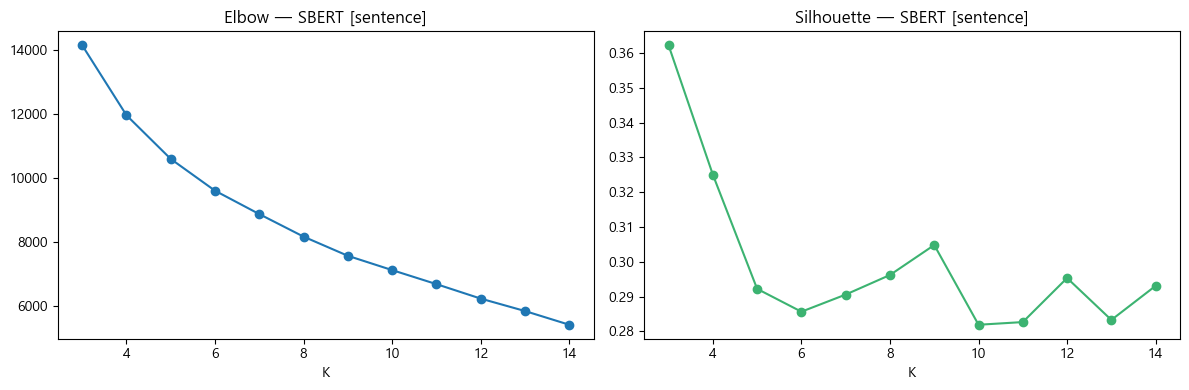

Silhouette 기준 최적 K = 3


In [ ]:
reducer_10d = umap.UMAP(n_components=10, metric="cosine", random_state=42)
reduced_10d = reducer_10d.fit_transform(embeddings)

K_RANGE = range(3, 15)
inertias_s, silhouettes_s = [], []

for k in tqdm(K_RANGE, desc="SBERT K 탐색"):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(reduced_10d)
    inertias_s.append(km.inertia_)
    silhouettes_s.append(silhouette_score(reduced_10d, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias_s, marker="o")
axes[0].set_title(f"Elbow — SBERT [{ANALYSIS_MODE}]"); axes[0].set_xlabel("K")
axes[1].plot(list(K_RANGE), silhouettes_s, marker="o", color="mediumseagreen")
axes[1].set_title(f"Silhouette — SBERT [{ANALYSIS_MODE}]"); axes[1].set_xlabel("K")
plt.tight_layout(); plt.savefig(f"sbert_optimal_k_{ANALYSIS_MODE}.png", dpi=150); plt.show()

best_k_sbert = list(K_RANGE)[silhouettes_s.index(max(silhouettes_s))]
print(f"Silhouette 기준 최적 K = {best_k_sbert}")

### 3-3. KMeans 군집화 & UMAP 2D 시각화

군집별 문장 수 (SBERT):
cluster_sbert
0    1498
1    2649
2    1600
3    1601
Name: count, dtype: int64


C:\Users\LeeChiHeon\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\LeeChiHeon\AppData\Local\Temp\ipykernel_4324\2384680763.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_s = plt.cm.get_cmap("tab10", N_SBERT)


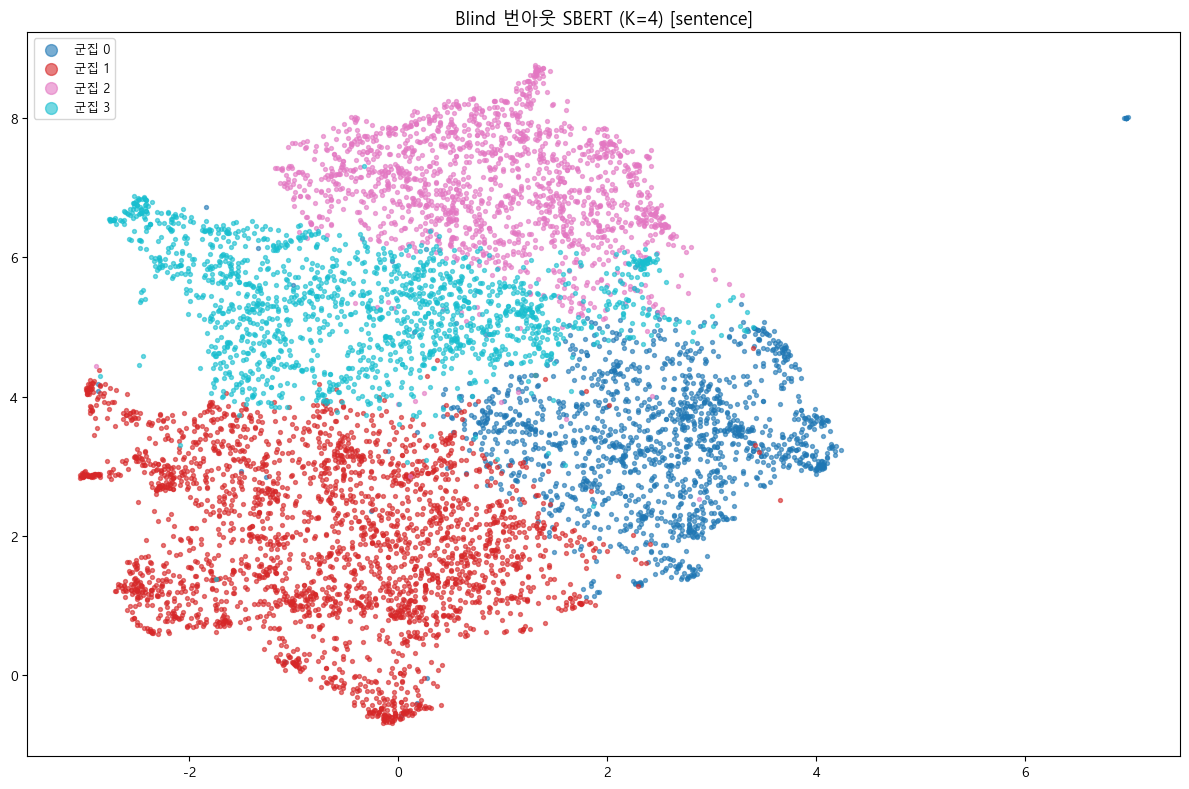

In [ ]:
N_SBERT = 4   # 직접 수정 가능: N_SBERT = 7

km_sbert = KMeans(n_clusters=N_SBERT, random_state=42, n_init=10)
analysis_df["cluster_sbert"] = km_sbert.fit_predict(reduced_10d)
print(f"군집별 {'문장' if ANALYSIS_MODE == 'sentence' else '게시글'} 수 (SBERT):")
print(analysis_df["cluster_sbert"].value_counts().sort_index())

reducer_2d = umap.UMAP(n_components=2, metric="cosine", random_state=42)
xy_s = reducer_2d.fit_transform(embeddings)

cmap_s = plt.cm.get_cmap("tab10", N_SBERT)
plt.figure(figsize=(12, 8))
for c in range(N_SBERT):
    mask = analysis_df["cluster_sbert"] == c
    plt.scatter(xy_s[mask, 0], xy_s[mask, 1], s=8, alpha=0.6,
                color=cmap_s(c), label=f"군집 {c}")
plt.legend(markerscale=3, fontsize=9)
plt.title(f"Blind 번아웃 SBERT (K={N_SBERT}) [{ANALYSIS_MODE}]", fontsize=13)
plt.tight_layout(); plt.savefig(f"sbert_cluster_2d_{ANALYSIS_MODE}.png", dpi=150); plt.show()

### 3-4. 군집별 키워드(TF-IDF) & 대표 텍스트(코사인 유사도)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

tfidf_raw = TfidfVectorizer(max_features=5000)
tfidf_raw.fit(analysis_df[TEXT_COL])
feature_names_raw = tfidf_raw.get_feature_names_out()

unit = "문장" if ANALYSIS_MODE == "sentence" else "게시글"
print("=" * 70)
for c in range(N_SBERT):
    idx = analysis_df[analysis_df["cluster_sbert"] == c].index.tolist()
    cluster_embs = embeddings[idx]
    centroid = cluster_embs.mean(axis=0, keepdims=True)
    sims = cosine_similarity(centroid, cluster_embs)[0]
    top5 = [idx[i] for i in sims.argsort()[::-1][:5]]

    mat = tfidf_raw.transform(analysis_df.loc[idx, TEXT_COL].tolist())
    keywords = [feature_names_raw[i]
                for i in mat.mean(axis=0).A1.argsort()[::-1][:20]]

    print(f"\n【SBERT 군집 {c}】 ({len(idx)}{unit})")
    print(f"  키워드: {' | '.join(keywords)}")
    print(f"  대표 {unit}:")
    for rank, g in enumerate(top5, 1):
        preview = analysis_df.loc[g, TEXT_COL]
        print(f"    {rank}. {preview[:80]}{'...' if len(preview) > 80 else ''}")
print("=" * 70)


【SBERT 군집 0】 (1498문장)
  키워드: 너무 | 모르겠어 | 내가 | 그냥 | 진짜 | 어떻게 | 혹시 | 근데 | 이런 | 있을까 | 이렇게 | 그래서 | 이게 | 이거 | 그럼 | 모르겠네 | 모르겠다 | 모르겠어서 | 일단 | 뭐가
  대표 문장:
    1. 이거 물어봐야 하는건가...
    2. 근데 좀 고민되긴 한다..
    3. 근데 급하게 찾아면 또 애매해질까바서  어쩌지
    4. 혹시 어디 불편하신분인가 싶기도하고....
    5. 사실 여기물어도 되나싶긴한데 내일 다시 전화해보기 전에 좀 알고싶어서

【SBERT 군집 1】 (2649문장)
  키워드: 그냥 | 근데 | 내가 | 너무 | 많이 | 에어컨 | 그래서 | 하고 | 진짜 | 화장실 | 냉장고 | 사서 | 침대 | 세탁기 | 있어서 | 없어서 | 지금 | 했는데 | 베란다 | 모르겠어
  대표 문장:
    1. 이불같은거만 21키로에 돌리고 평소에는 그냥 이걸 쓰는거지 양말속옷수건 러그 이런거 다 여기에 돌렸었는데 뽀송하고 아무문제 없었거든 근데 그럼 ...
    2. 그리거 다 하면 내가 집 들어기서 냉장고 세탁기 에어컨 받기로 해서 괜찮은지 확인할거같거 커튼도 받기로 해써 있으면 떼던가 해야할듯?
    3. 미니건조를 다시산다 배관때매 세탁실에 두면 습기나가는 배관이 복도식 창문쪽이라 복도에 습기차면 욕먹을거같음...
    4. 도배 장판 이랑  가전 들어오는거 생각 하면  집근처가 나은가 싶고
    5. 1년 살지 2년 살지 모르는데 여기 에어컨이 없고 월세라 그냥 에어컨 렌탈로 써볼까도 싶거든 ...새로 사서 설치하자니 50이상부터 깨지는거같고...

【SBERT 군집 2】 (1600문장)
  키워드: 내가 | 대출 | 보증금 | 근데 | 부동산 | 집주인이 | 계약 | 월세 | 지금 | 전세 | 계약서 | 보증보험 | 너무 | 부동산에 | 나는 | 그냥 | 그럼 | 일단 | 하고 | 하는데
  대표 문장:
    1. 전세대출은 계약서 써야 나

---
## 세 방법 나란히 비교 (UMAP 2D)

## 결과 저장

In [ ]:
output_csv   = f"{RAW_CSV}_{ANALYSIS_MODE}.csv"
output_model = f"{RAW_CSV}_{ANALYSIS_MODE}.model"

analysis_df.to_csv(output_csv, index=False, encoding="utf-8-sig")
#d2v.save(output_model)

print("저장 완료 ✅")
print(f"  → {output_csv}")
print(f"  → {output_model}")
print(f"  → tfidf/d2v/sbert_cluster_2d_{ANALYSIS_MODE}.png")
print(f"  → {RAW_CSV}_{ANALYSIS_MODE}.png")
analysis_df.head()

저장 완료 ✅
  → ./Data/theqoo_자취_결과.csv_filtered_output.csv_document.csv
  → ./Data/theqoo_자취_결과.csv_filtered_output.csv_document.model
  → tfidf/d2v/sbert_cluster_2d_document.png
  → ./Data/theqoo_자취_결과.csv_filtered_output.csv_document.png


,doc_idx,text,tokens,tokens_str,cluster_sbert
0,0,벽간소음은 진짜 살아보기 전엔 모르나봐.. 햇빛도 잘 들어오고 층고도 높아서 집은 ...,"[소음, 모르, 햇빛, 들어오, 층고, 옆집, 이사, 생각, 생활, 소음, 어쩌, ...",소음 모르 햇빛 들어오 층고 옆집 이사 생각 생활 소음 어쩌 망치 소리 화장실 하루...,2
1,1,지금 살고 있는 집 계약 끝나면 옮길까 고민중인데\n계약 만료 3개월 전에 집주인한...,"[계약, 끝나, 옮기, 고민, 계약, 만료, 집주인, 나가, 지금, 만료, 시점, ...",계약 끝나 옮기 고민 계약 만료 집주인 나가 지금 만료 시점 주변 알아보 옮기 어쩌...,1
2,2,자취방 작은 냉장고 수평이 약간 안맞아서 문열고닫을때 흔들렸었는데 별로 안 불편해서...,"[자취방, 냉장고, 수평, 흔들리, 불편, 귀찮, 박스, 자르, 끼우, 새벽, 끼우...",자취방 냉장고 수평 흔들리 불편 귀찮 박스 자르 끼우 새벽 끼우 수평 미세 냉장고 ...,0
3,3,맨날 선물로 들어오는 2030 이런 거 쓰다가\n첨으로 치약 좋은 걸로 써 보고 싶...,"[선물, 치약, 모르, 게이트]",선물 치약 모르 게이트,0
4,4,직장은 역삼이고\n첫 독립이라서 모르는 것 투성이네\n네이버페이 부동산으로 알아보고...,"[직장, 역삼, 독립, 모르, 네이버, 페이, 부동산, 알아보, 비싸, 마포, 역삼...",직장 역삼 독립 모르 네이버 페이 부동산 알아보 비싸 마포 역삼 드리,1
